In [110]:
import numpy as np 
import pandas as pd  
import seaborn as sns  
import matplotlib.pyplot as plt

In [111]:
df = pd.read_csv("gold_price_data.csv")

In [112]:
df.head(10)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180000,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285000,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167000,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053000,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590000,1.557099
5,1/9/2008,1409.130005,86.550003,75.250000,15.520000,1.466405
6,1/10/2008,1420.329956,88.250000,74.019997,16.061001,1.480100
7,1/11/2008,1401.020020,88.580002,73.089996,16.077000,1.479006
8,1/14/2008,1416.250000,89.540001,74.250000,16.280001,1.486900
9,1/15/2008,1380.949951,87.989998,72.779999,15.834000,1.480210


In [113]:
df.dtypes

Date        object
SPX        float64
GLD        float64
USO        float64
SLV        float64
EUR/USD    float64
dtype: object

In [114]:
df['Date'] = df['Date'].astype('datetime64[ns]')

In [115]:
df.dtypes

Date       datetime64[ns]
SPX               float64
GLD               float64
USO               float64
SLV               float64
EUR/USD           float64
dtype: object

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [117]:
df.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371008,1654.315776,122.732875,31.842221,20.084997,1.283653
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547


=============Data preprocessing================

In [118]:
df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [119]:
co_relation = df.select_dtypes(include=['float64', 'int64']).corr()
co_relation

,SPX,GLD,USO,SLV,EUR/USD
SPX,1.000000,0.049345,-0.591573,-0.274055,-0.672017
GLD,0.049345,1.000000,-0.186360,0.866632,-0.024375
USO,-0.591573,-0.186360,1.000000,0.167547,0.829317
SLV,-0.274055,0.866632,0.167547,1.000000,0.321631
EUR/USD,-0.672017,-0.024375,0.829317,0.321631,1.000000


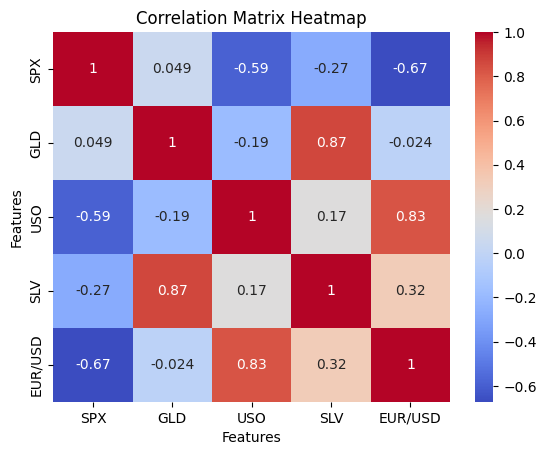

In [120]:
sns.heatmap(co_relation, cmap='coolwarm', annot=True)
plt.title('Correlation Matrix Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

In [121]:
df.drop("SLV", axis=1,inplace=True)

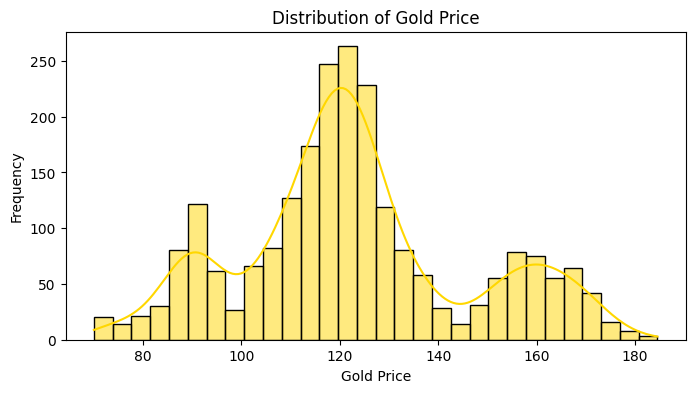

In [122]:
plt.figure(figsize=(8,4))
sns.histplot(df['GLD'], kde=True, bins=30, color='gold')
plt.title("Distribution of Gold Price")
plt.xlabel("Gold Price")
plt.ylabel("Frequency")
plt.show()

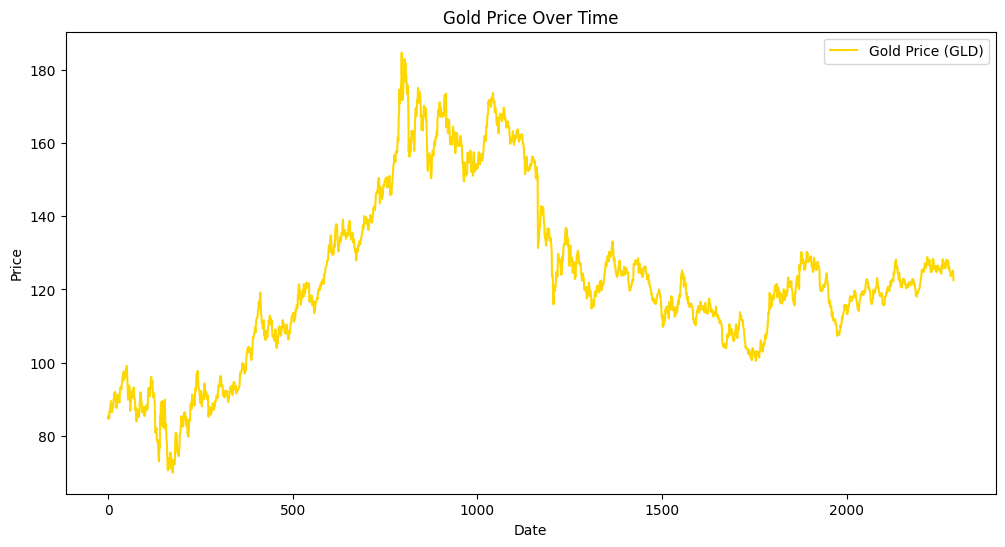

In [123]:
plt.figure(figsize=(12,6))
plt.plot(df.index, df['GLD'], color='gold', label='Gold Price (GLD)')
plt.title("Gold Price Over Time")
plt.xlabel("Date"); plt.ylabel("Price")
plt.legend(); plt.show()

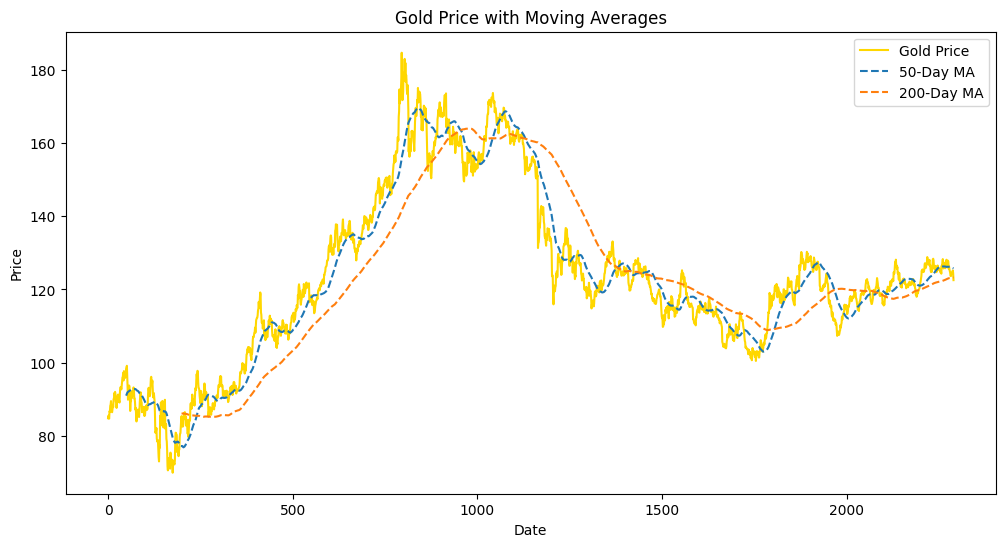

In [124]:
plt.figure(figsize=(12,6))
df['GLD'].plot(label="Gold Price", color='gold')
df['GLD'].rolling(50).mean().plot(label="50-Day MA", linestyle="--")
df['GLD'].rolling(200).mean().plot(label="200-Day MA", linestyle="--")
plt.title("Gold Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

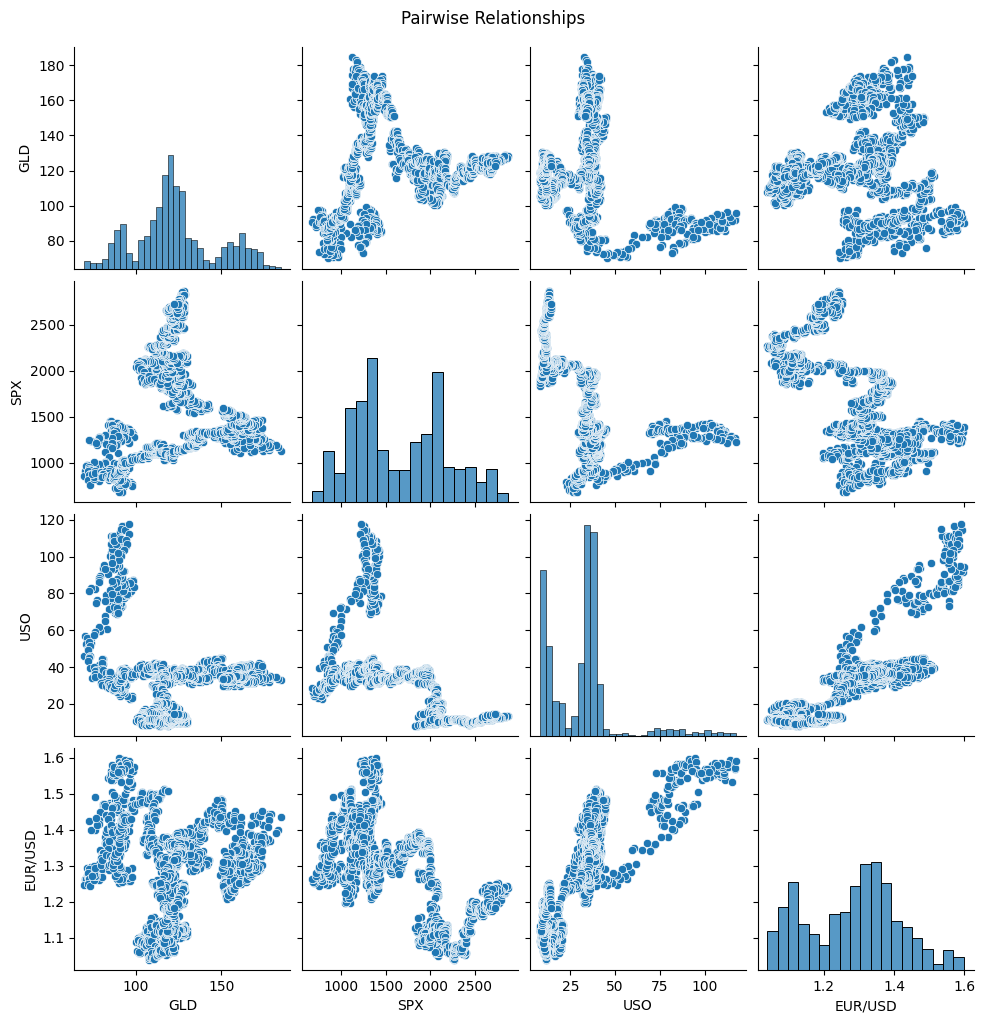

In [125]:
sns.pairplot(df[['GLD','SPX','USO','EUR/USD']])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

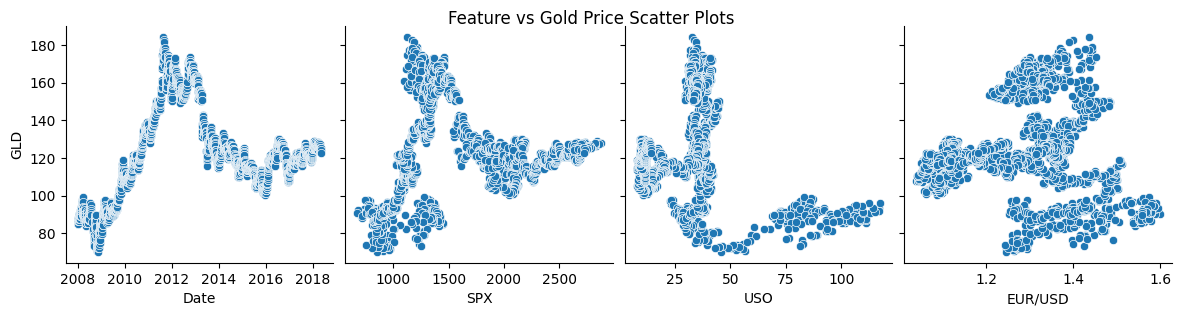

In [126]:
features = df.drop('GLD', axis=1).columns
sns.pairplot(df, x_vars=features, y_vars='GLD', kind='scatter', height=3)
plt.suptitle("Feature vs Gold Price Scatter Plots", y=1.02)
plt.show()

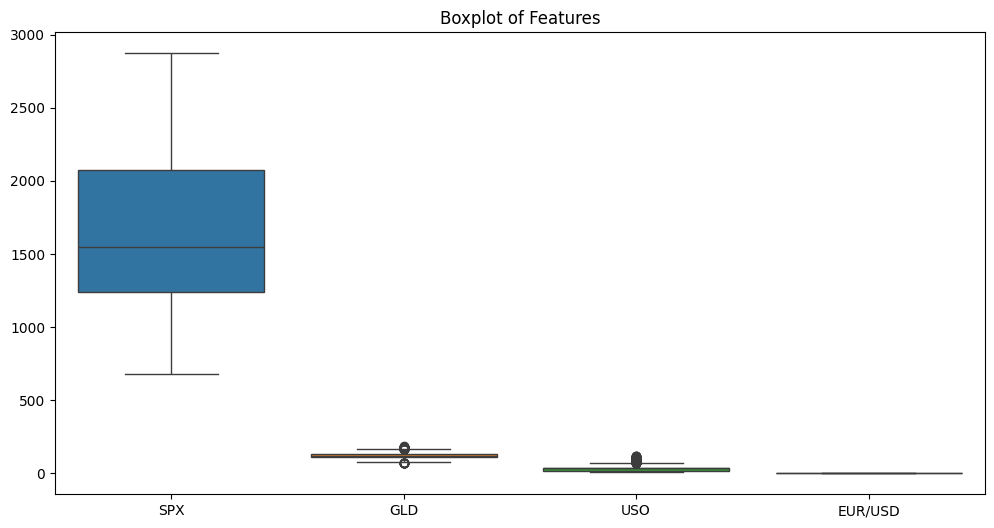

In [127]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Boxplot of Features")
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9244\441690737.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_target.index, y=corr_with_target.values, palette='viridis')


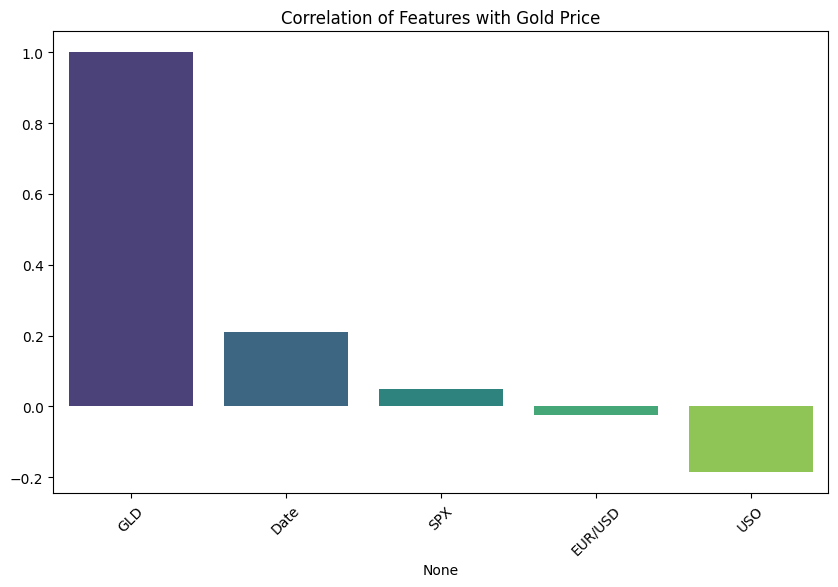

In [128]:
plt.figure(figsize=(10,6))
corr_with_target = df.corr()['GLD'].sort_values(ascending=False)
sns.barplot(x=corr_with_target.index, y=corr_with_target.values, palette='viridis')
plt.xticks(rotation=45)
plt.title("Correlation of Features with Gold Price")
plt.show()

In [129]:
X = df.drop(['Date', 'GLD'], axis=1)
y = df['GLD']

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb

In [131]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Linear regression

In [132]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [133]:
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

In [134]:
print("Polynomial Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Polynomial Regression R2 Score:", r2_score(y_test, y_pred_lr))


Polynomial Regression RMSE: 22.726401510400702
Polynomial Regression R2 Score: 0.058016735558848676


Random Forest Regressor

In [135]:
rf_params = {'n_estimators': [50, 80, 100],
              'max_depth': [3, 5, 7]}

In [136]:
rf_model = RandomForestRegressor(random_state=42)
rf_grid = GridSearchCV(estimator=rf_model, param_grid=rf_params, cv=3, scoring='r2')
rf_grid.fit(X_train, y_train)
y_pred_rf_best = rf_grid.best_estimator_.predict(X_test)

In [137]:
print("Random Forest Best Params:", rf_grid.best_params_)
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf_best)))
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf_best))

Random Forest Best Params: {'max_depth': 7, 'n_estimators': 50}
Random Forest RMSE: 6.3877947960457515
Random Forest R2 Score: 0.9255810138230165


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9244\2519139274.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=X_train.columns, y=importances, palette='viridis')


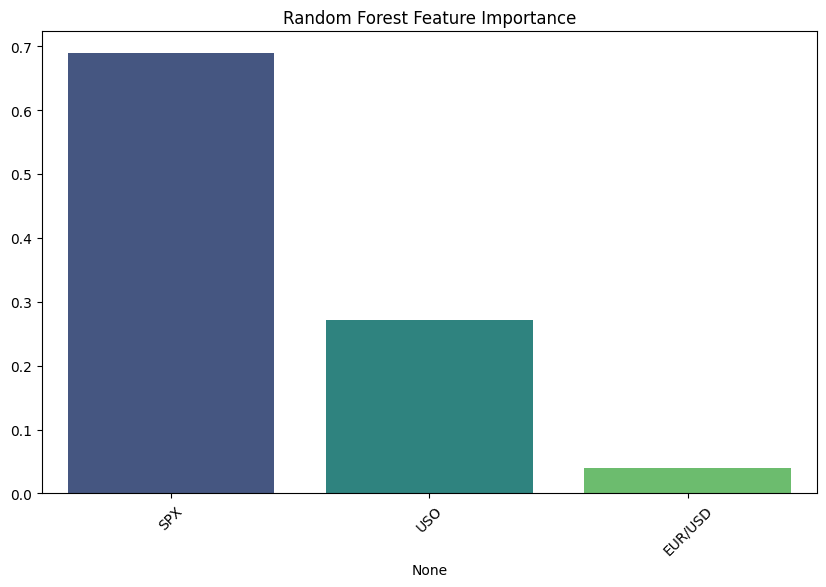

In [138]:
importances = rf_grid.best_estimator_.feature_importances_
plt.figure(figsize=(10,6))
sns.barplot(x=X_train.columns, y=importances, palette='viridis')
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.show()


XGBoost Regressor

In [139]:
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}

In [140]:
xgbr_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

In [141]:
xgb_grid = GridSearchCV(estimator=xgbr_model, param_grid=xgb_params, cv=3, scoring='r2')
xgb_grid.fit(X_train, y_train)
y_pred_xgb_best = xgb_grid.best_estimator_.predict(X_test)

In [142]:
print("XGBoost Best Params:", xgb_grid.best_params_)
print("XGBoost RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb_best)))
print("XGBoost R2 Score:", r2_score(y_test, y_pred_xgb_best))

XGBoost Best Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
XGBoost RMSE: 5.556919496264488
XGBoost R2 Score: 0.9436816338429688


<Figure size 1000x600 with 0 Axes>

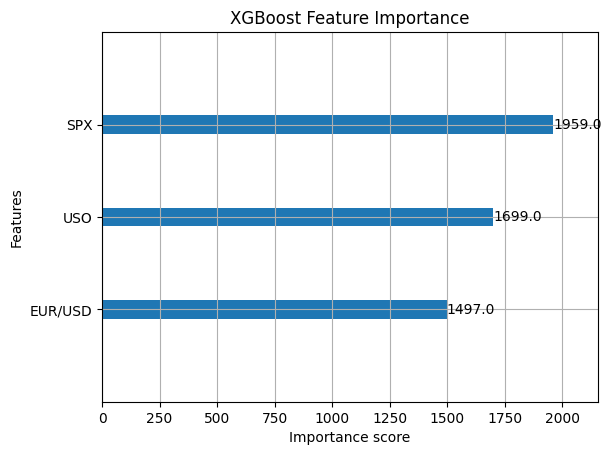

In [143]:
plt.figure(figsize=(10,6))
xgb.plot_importance(xgb_grid.best_estimator_)
plt.title("XGBoost Feature Importance")
plt.show()

In [144]:
def plot_pred_vs_actual(y_test, y_pred, model_name, color):
    plt.figure(figsize=(12,6))
    plt.plot(y_test.values, label='Actual Gold Price', color='gold')
    plt.plot(y_pred, label=f'Predicted ({model_name})', color=color, alpha=0.7)
    plt.title(f"Actual vs Predicted Gold Price - {model_name}")
    plt.xlabel("Test Data Index")
    plt.ylabel("Gold Price")
    plt.legend()
    plt.show()
    
    # Scatter plot
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=y_test, y=y_pred, color=color)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"{model_name} Predicted vs Actual Gold Prices")
    plt.xlabel("Actual Gold Price")
    plt.ylabel("Predicted Gold Price")
    plt.show()

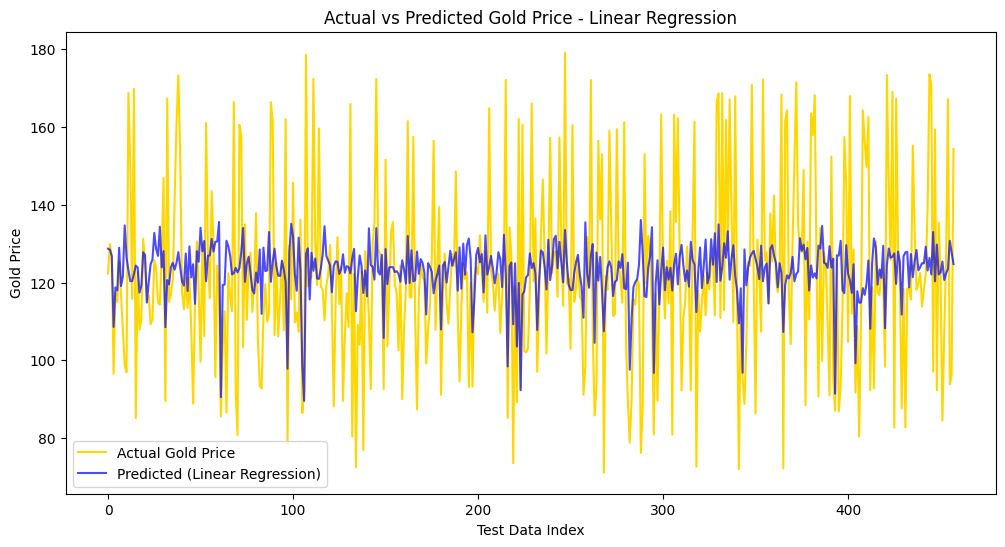

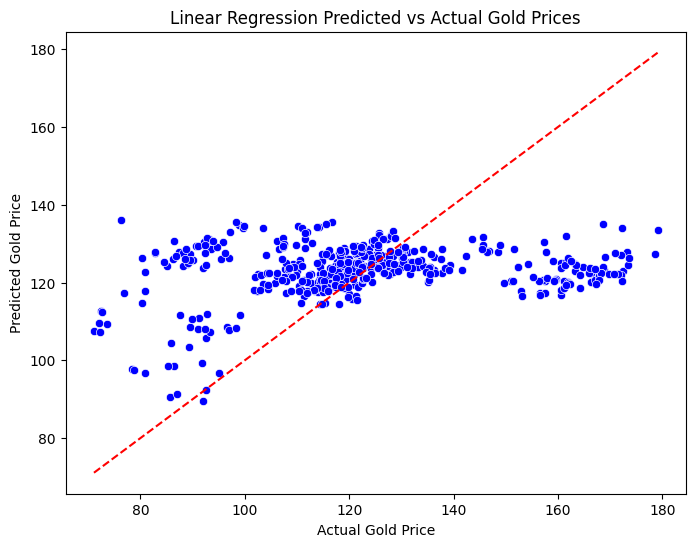

In [145]:
plot_pred_vs_actual(y_test, y_pred_lr, "Linear Regression", "blue")

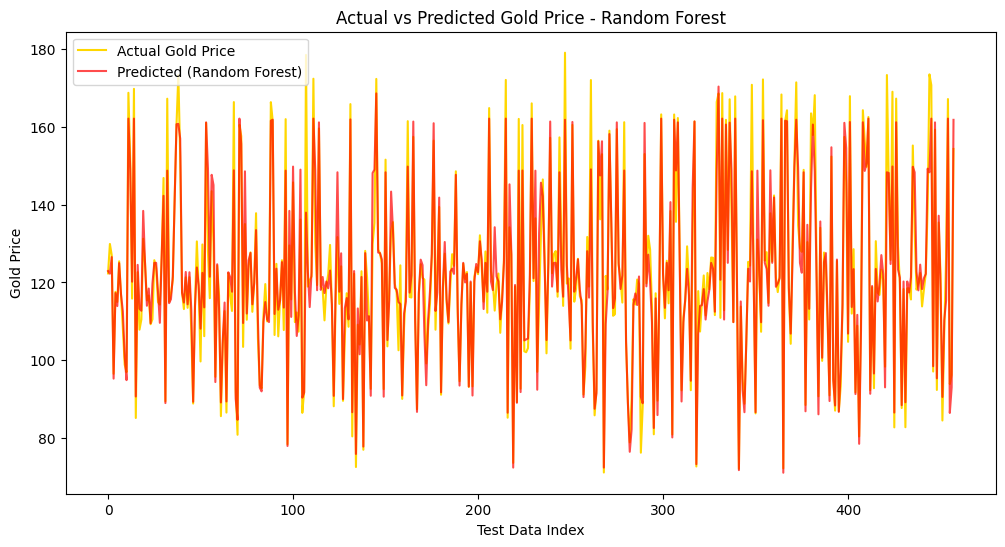

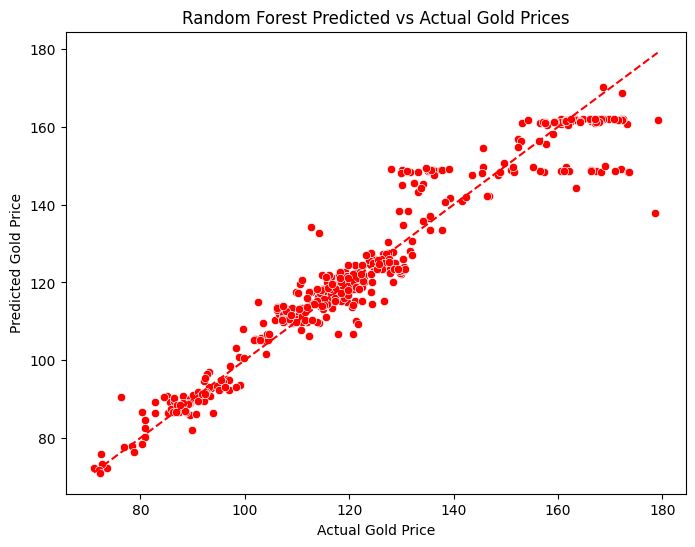

In [146]:
plot_pred_vs_actual(y_test, y_pred_rf_best, "Random Forest", "red")

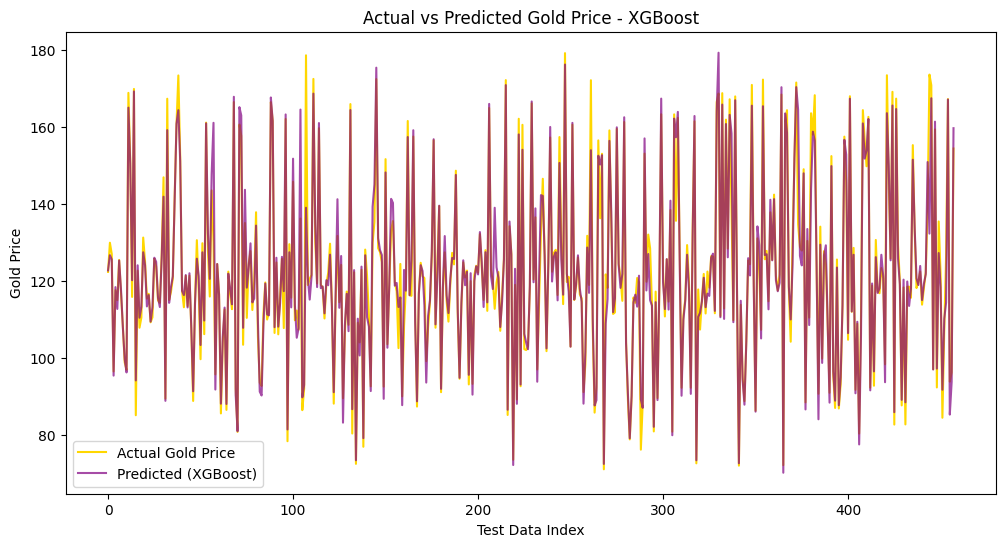

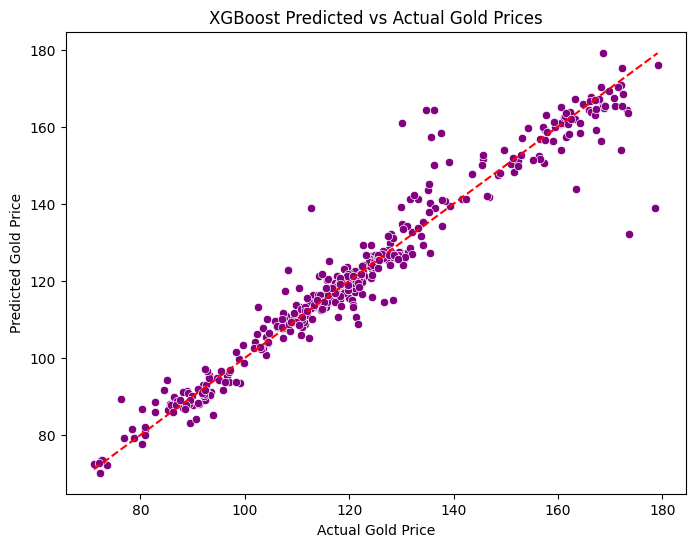

In [147]:
plot_pred_vs_actual(y_test, y_pred_xgb_best, "XGBoost", "purple")